In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("Fraud Detection Dataset.csv")
print(df.shape)
df.head()

(51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [4]:
df.columns.tolist()
list(df)

['Transaction_ID',
 'User_ID',
 'Transaction_Amount',
 'Transaction_Type',
 'Time_of_Transaction',
 'Device_Used',
 'Location',
 'Previous_Fraudulent_Transactions',
 'Account_Age',
 'Number_of_Transactions_Last_24H',
 'Payment_Method',
 'Fraudulent']

In [5]:
df=df.dropna()

In [6]:
missing_percent = df.isnull().mean()*100

print(missing_percent)

Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64


In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 688


In [8]:
# Task 1: Column-wise duplicate count
# For each column: how many values repeat a value already seen above in that column
dup_cols = pd.DataFrame({
    "unique_values": df.nunique(),
    "duplicate_values": df.apply(lambda s: s.duplicated().sum()),
})
dup_cols["duplicate_%"] = (dup_cols["duplicate_values"] / len(df) * 100).round(2)
print(dup_cols.sort_values("duplicate_%"))

# Transaction_ID should be unique - repeats here mean the same transaction was recorded twice
print("\nRepeated Transaction_IDs:", df["Transaction_ID"].duplicated().sum())

                                  unique_values  duplicate_values  duplicate_%
Transaction_ID                            38796               787         1.99
Transaction_Amount                        36916              2667         6.74
User_ID                                    4000             35583        89.89
Account_Age                                 119             39464        99.70
Time_of_Transaction                          24             39559        99.94
Number_of_Transactions_Last_24H              14             39569        99.96
Location                                      8             39575        99.98
Transaction_Type                              5             39578        99.99
Previous_Fraudulent_Transactions              5             39578        99.99
Device_Used                                   4             39579        99.99
Payment_Method                                5             39578        99.99
Fraudulent                                    2     

In [9]:
# Remove full-row duplicates before further analysis
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (38895, 12)


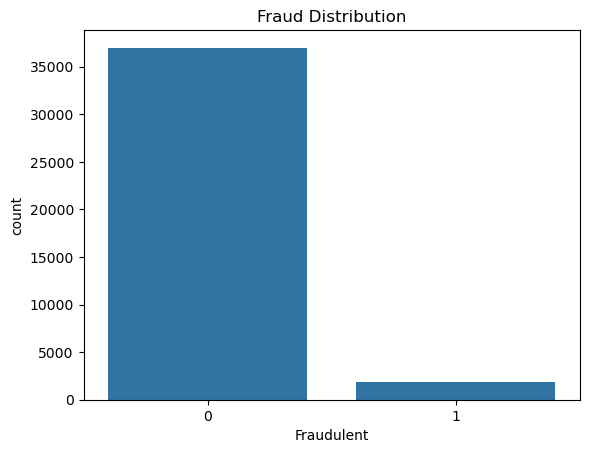

In [10]:
sns.countplot(x="Fraudulent", data=df)

plt.title("Fraud Distribution")

plt.show()

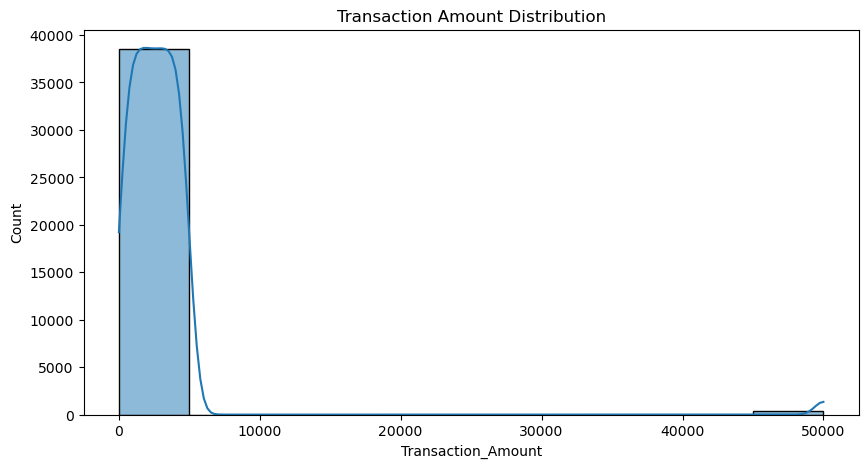

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Transaction_Amount"],
    bins=10,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

Fraudulent          0     1    All
Payment_Method                    
Credit Card      8836   451   9287
Debit Card       9012   456   9468
Invalid Method   1172    56   1228
Net Banking      8876   463   9339
UPI              9100   473   9573
All             36996  1899  38895

Fraud rate (%) by payment method:
Payment_Method
Net Banking       4.96
UPI               4.94
Credit Card       4.86
Debit Card        4.82
Invalid Method    4.56
Name: Fraudulent, dtype: float64


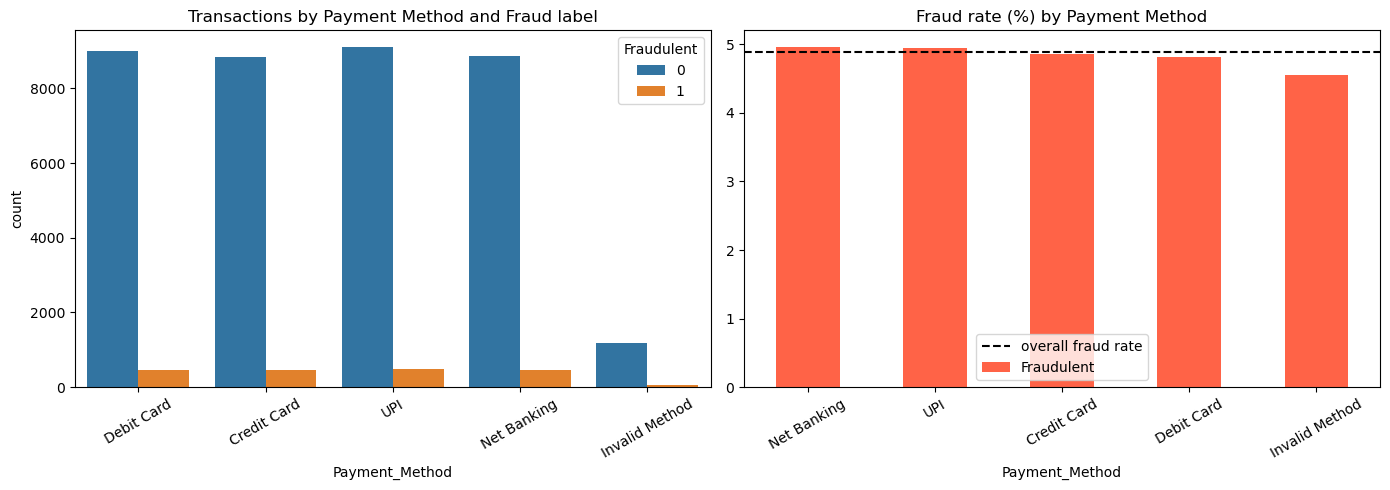

In [12]:
# Task 2: Payment_Method vs Fraudulent (grouping / "cluster" view)
ct = pd.crosstab(df["Payment_Method"], df["Fraudulent"], margins=True)
print(ct)

fraud_rate = (df.groupby("Payment_Method")["Fraudulent"].mean() * 100).sort_values(ascending=False)
print("\nFraud rate (%) by payment method:")
print(fraud_rate.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="Payment_Method", hue="Fraudulent", ax=axes[0])
axes[0].set_title("Transactions by Payment Method and Fraud label")
axes[0].tick_params(axis="x", rotation=30)

fraud_rate.plot(kind="bar", ax=axes[1], color="tomato")
axes[1].axhline(df["Fraudulent"].mean() * 100, ls="--", c="k", label="overall fraud rate")
axes[1].set_title("Fraud rate (%) by Payment Method")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [13]:
# Is the link between Payment_Method and fraud statistically significant? (chi-square test)
from scipy.stats import chi2_contingency
chi2_stat, p, dof, _ = chi2_contingency(pd.crosstab(df["Payment_Method"], df["Fraudulent"]))
print(f"Chi-square = {chi2_stat:.2f}, p-value = {p:.4f}")
print("Significant association" if p < 0.05 else "No significant association")

Chi-square = 0.56, p-value = 0.9672
No significant association


<Axes: >

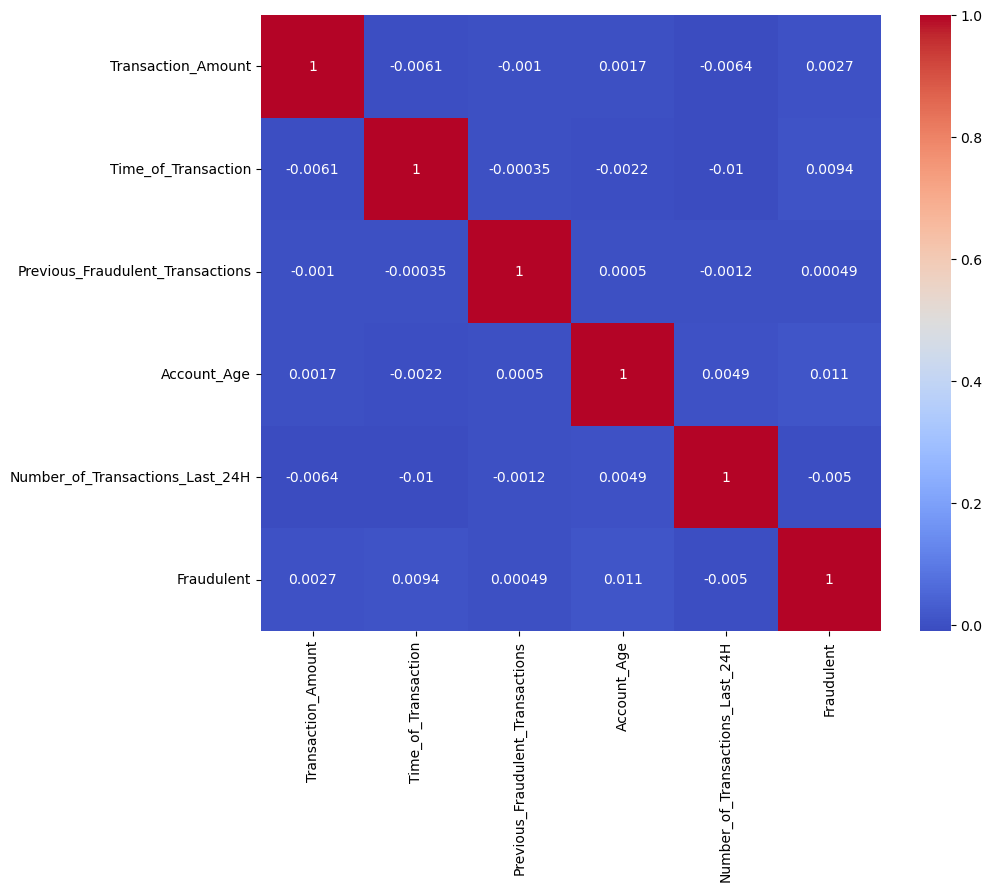

In [15]:
numeric = df.select_dtypes(include="number").drop(columns=["User_ID"])

plt.figure(figsize=(10,8))

sns.heatmap(

numeric.corr(),

annot=True,

cmap="coolwarm"

)

# Outlier 

Text(0.5, 1.0, 'Transaction Amount Boxplot')

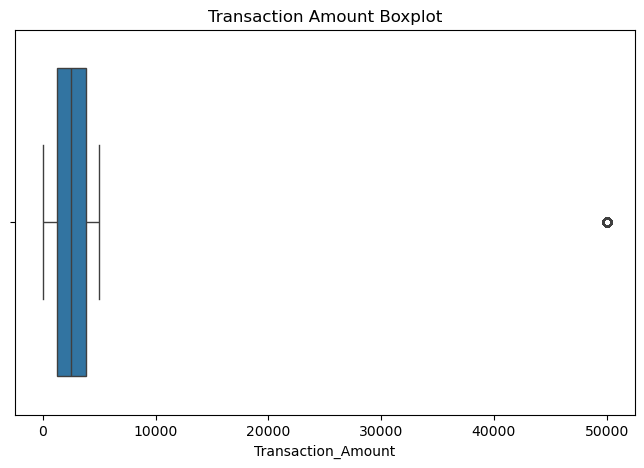

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Transaction_Amount"]
)

plt.title("Transaction Amount Boxplot")

In [17]:
Q1 = df["Transaction_Amount"].quantile(0.25)

Q3 = df["Transaction_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR


outliers = df[
    (df["Transaction_Amount"] < lower) |
    (df["Transaction_Amount"] > upper)
]

#Lower_outlier= df[df["Transaction_Amount"] < lower]

#Lower_outlier.head()

#upper_outlier= df[df["Transaction_Amount"] < upper]

#upper_outlier.head()
#upper_outlier.shape
#Lower_outlier.shape
print(outliers.shape)
#outliers.head()

(411, 12)


IQR bounds: -13.00 to 35.00
IQR outliers: 0
Invalid hours (outside 0-23): 0


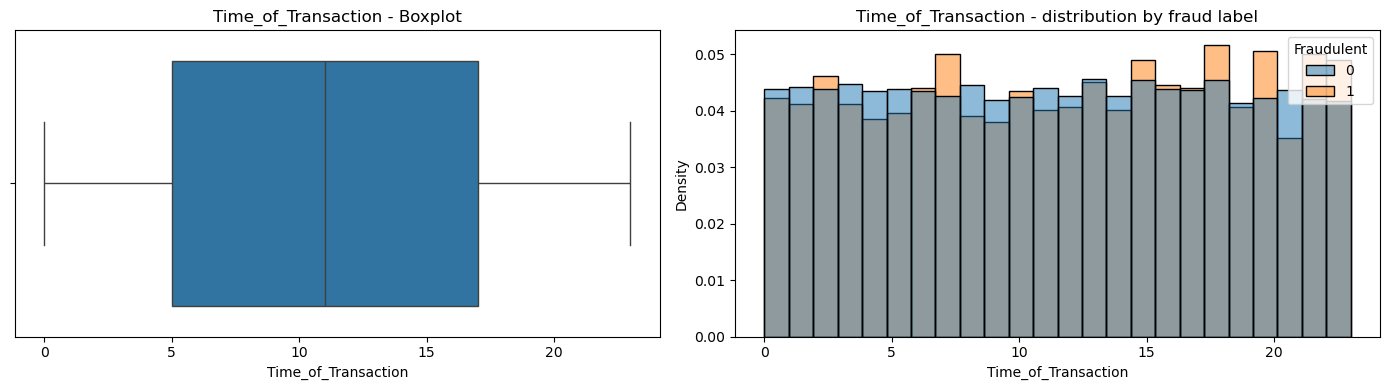

In [18]:
# Task 2 (Outliers): Time_of_Transaction
col = "Time_of_Transaction"
Q1_t = df[col].quantile(0.25)
Q3_t = df[col].quantile(0.75)
IQR_t = Q3_t - Q1_t
lower_t = Q1_t - 1.5 * IQR_t
upper_t = Q3_t + 1.5 * IQR_t

iqr_outliers = df[(df[col] < lower_t) | (df[col] > upper_t)]
# Hour of day must lie in 0-23; anything else is an invalid value even if IQR doesn't flag it
invalid_hours = df[(df[col] < 0) | (df[col] > 23)]

print(f"IQR bounds: {lower_t:.2f} to {upper_t:.2f}")
print("IQR outliers:", len(iqr_outliers))
print("Invalid hours (outside 0-23):", len(invalid_hours))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title("Time_of_Transaction - Boxplot")
sns.histplot(data=df, x=col, hue="Fraudulent", bins=24, stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Time_of_Transaction - distribution by fraud label")
plt.tight_layout()
plt.show()

In [19]:
# Task 3: Common / uncommon values
rare_threshold = 0.01   # a value is "uncommon" if it appears in < 1% of rows

cat_cols = df.select_dtypes(exclude="number").columns.drop("Transaction_ID")
for c in cat_cols:
    freq = df[c].value_counts(normalize=True)
    print(f"\n=== {c} ===")
    print("Most common :", freq.index[0], f"({freq.iloc[0]*100:.1f}%)")
    print("Least common:", freq.index[-1], f"({freq.iloc[-1]*100:.2f}%)")
    rare = freq[freq < rare_threshold]
    print("Uncommon values (<1%):", rare.index.tolist() if len(rare) else "none")


=== Transaction_Type ===
Most common : Bank Transfer (20.3%)
Least common: Online Purchase (19.82%)
Uncommon values (<1%): none

=== Device_Used ===
Most common : Desktop (32.5%)
Least common: Unknown Device (3.18%)
Uncommon values (<1%): none

=== Location ===
Most common : Boston (12.7%)
Least common: Houston (12.34%)
Uncommon values (<1%): none

=== Payment_Method ===
Most common : UPI (24.6%)
Least common: Invalid Method (3.16%)
Uncommon values (<1%): none


In [20]:
# Numeric columns: most common value and values that occur suspiciously often
num_cols = ["Transaction_Amount", "Time_of_Transaction", "Previous_Fraudulent_Transactions",
            "Account_Age", "Number_of_Transactions_Last_24H"]
for c in num_cols:
    vc = df[c].value_counts()
    print(f"{c}: mode = {vc.index[0]} (x{vc.iloc[0]}), unique values = {df[c].nunique()}")

# A continuous amount repeating many times (e.g. 49997.8) is a red flag worth reporting
amount_repeats = df["Transaction_Amount"].value_counts()
print("\nTransaction amounts repeated > 5 times:")
print(amount_repeats[amount_repeats > 5])

Transaction_Amount: mode = 49997.8 (x411), unique values = 36916
Time_of_Transaction: mode = 18.0 (x1704), unique values = 24
Previous_Fraudulent_Transactions: mode = 2 (x7925), unique values = 5
Account_Age: mode = 45 (x371), unique values = 119
Number_of_Transactions_Last_24H: mode = 5 (x2881), unique values = 14

Transaction amounts repeated > 5 times:
Transaction_Amount
49997.8    411
Name: count, dtype: int64


In [21]:
features = [
    "Transaction_Amount",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H"
]


In [22]:
from sklearn.preprocessing import StandardScaler

X = df[features]
#X=X.dropna()
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [23]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=15
)

labels = dbscan.fit_predict(X_scaled)

In [24]:
df["Cluster"] = labels
#df.head()
df["Cluster"].value_counts()

Cluster
 0    38484
 1      403
-1        8
Name: count, dtype: int64

In [25]:
# How does fraud rate differ across DBSCAN clusters?
df.groupby("Cluster")["Fraudulent"].agg(transactions="count", fraud_rate="mean").round(4)

,transactions,fraud_rate
Cluster,,
-1,8,0.2500
0,38484,0.0487
1,403,0.0546


In [26]:
suspicious = df[df["Cluster"] == -1]

print(suspicious.head())

      Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
239             T318     4681             49997.8     Bill Payment   
6306           T8147     1640             49997.8     Bill Payment   
12051         T15442     4030             49997.8    Bank Transfer   
15526         T19825     2206             49997.8  Online Purchase   
17275         T22059     3612             49997.8    Bank Transfer   

       Time_of_Transaction Device_Used     Location  \
239                    0.0      Mobile      Houston   
6306                  17.0      Tablet  Los Angeles   
12051                 20.0     Desktop      Seattle   
15526                 14.0      Mobile        Miami   
17275                 20.0      Tablet     New York   

       Previous_Fraudulent_Transactions  Account_Age  \
239                                   4            4   
6306                                  4            7   
12051                                 0            5   
15526                   

### Task 4: Anomalies with a different feature set

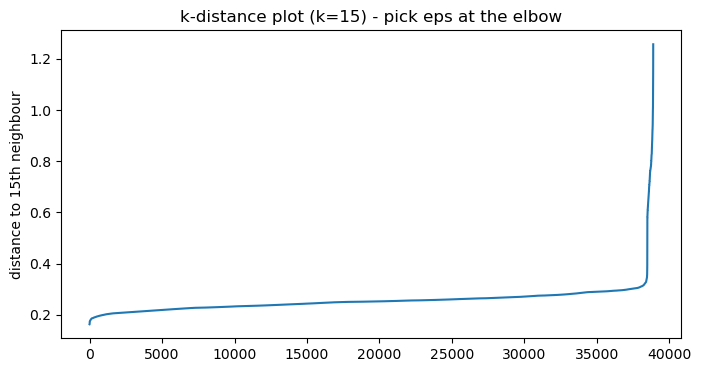

In [27]:
# Task 4: Anomalies (-1) with a DIFFERENT feature set
from sklearn.neighbors import NearestNeighbors

features_2 = ["Transaction_Amount", "Time_of_Transaction", "Account_Age", "Number_of_Transactions_Last_24H"]
X2_scaled = StandardScaler().fit_transform(df[features_2])

# k-distance plot to choose eps: eps ~ where the curve bends sharply ("elbow")
k = 15
dist, _ = NearestNeighbors(n_neighbors=k).fit(X2_scaled).kneighbors(X2_scaled)
plt.figure(figsize=(8, 4))
plt.plot(np.sort(dist[:, -1]))
plt.title(f"k-distance plot (k={k}) - pick eps at the elbow")
plt.ylabel(f"distance to {k}th neighbour")
plt.show()

In [28]:
eps_2 = 0.8          # adjust after looking at the k-distance plot
dbscan_2 = DBSCAN(eps=eps_2, min_samples=k)
df["Cluster_2"] = dbscan_2.fit_predict(X2_scaled)

print(df["Cluster_2"].value_counts())

anomalies_2 = df[df["Cluster_2"] == -1]
print("\nAnomalies with feature set 2:", len(anomalies_2))
print("Fraud rate among anomalies:", round(anomalies_2["Fraudulent"].mean(), 4))
print("Fraud rate among normal   :", round(df.loc[df["Cluster_2"] != -1, "Fraudulent"].mean(), 4))

# Overlap with the first feature set's anomalies
both = df[(df["Cluster"] == -1) & (df["Cluster_2"] == -1)]
print("Flagged by both feature sets:", len(both))
anomalies_2.head()

Cluster_2
0    38484
1      411
Name: count, dtype: int64

Anomalies with feature set 2: 0
Fraud rate among anomalies: nan
Fraud rate among normal   : 0.0488
Flagged by both feature sets: 0


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Cluster,Cluster_2


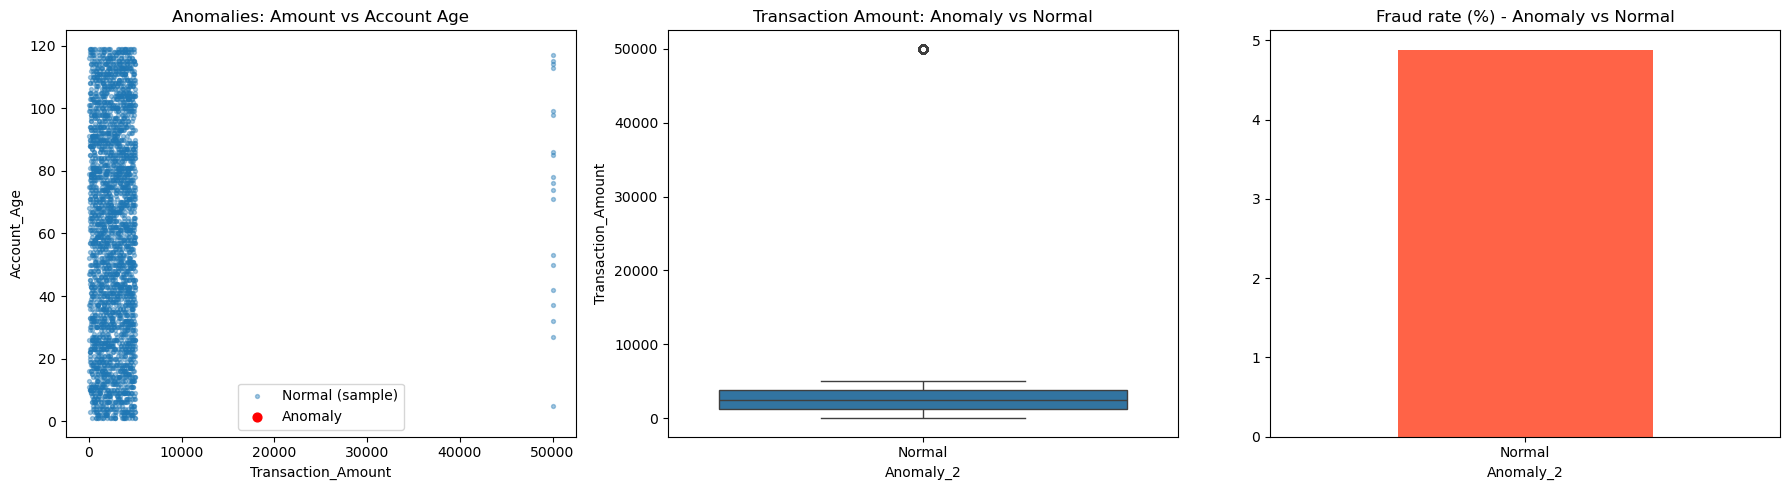

In [29]:
# Task 5: Graphs for anomalies (feature set 2)
df["Anomaly_2"] = np.where(df["Cluster_2"] == -1, "Anomaly", "Normal")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

normal_sample = df[df["Anomaly_2"] == "Normal"].sample(n=min(3000, (df["Anomaly_2"] == "Normal").sum()), random_state=42)
axes[0].scatter(normal_sample["Transaction_Amount"], normal_sample["Account_Age"], s=8, alpha=0.4, label="Normal (sample)")
axes[0].scatter(anomalies_2["Transaction_Amount"], anomalies_2["Account_Age"], s=40, c="red", label="Anomaly")
axes[0].set_xlabel("Transaction_Amount"); axes[0].set_ylabel("Account_Age")
axes[0].set_title("Anomalies: Amount vs Account Age"); axes[0].legend()

sns.boxplot(data=df, x="Anomaly_2", y="Transaction_Amount", ax=axes[1])
axes[1].set_title("Transaction Amount: Anomaly vs Normal")

(df.groupby("Anomaly_2")["Fraudulent"].mean() * 100).plot(kind="bar", ax=axes[2], color=["tomato", "steelblue"])
axes[2].set_title("Fraud rate (%) - Anomaly vs Normal"); axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Task 5: Cluster Graph (any two attributes)

In [30]:
x_attr = "Transaction_Amount"   
y_attr = "Previous_Fraudulent_Transactions"          


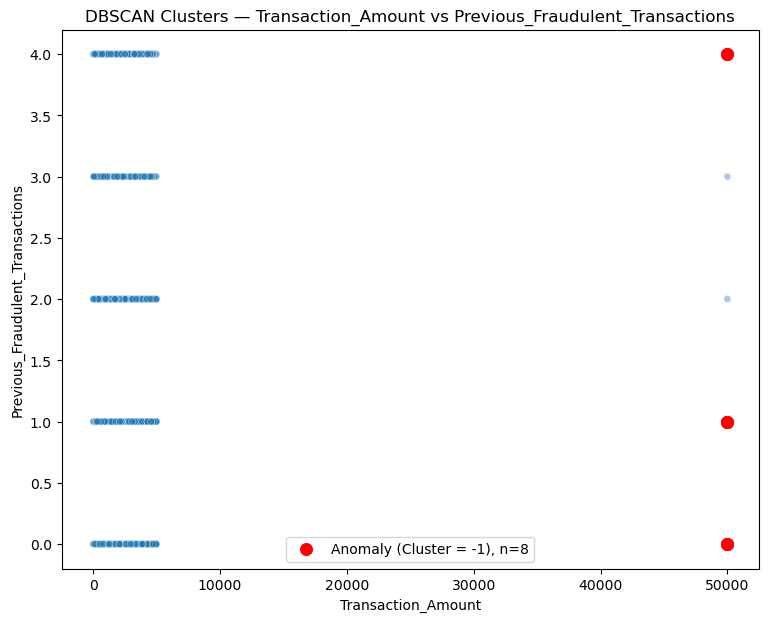

In [31]:
non_noise = df[df["Cluster"] != -1]
noise = df[df["Cluster"] == -1]

sample_size = min(3000, len(non_noise))
plot_sample = non_noise.sample(n=sample_size, random_state=42)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=plot_sample,
    x=x_attr, y=y_attr,
    hue="Cluster",
    palette="tab20",
    alpha=0.6, s=25,
    legend=False
)

plt.scatter(
    noise[x_attr], noise[y_attr],
    c="red", marker="o", s=70,
    label=f"Anomaly (Cluster = -1), n={len(noise)}"
)

plt.xlabel(x_attr)
plt.ylabel(y_attr)
plt.title(f"DBSCAN Clusters — {x_attr} vs {y_attr}")
plt.legend()
plt.show()
